In [1]:
import pandas as pd
from pathlib import Path

from hcc_multimodal.baselines.transforms import (
    CLINICAL_X_COLUMNS,
    DataType,
    build_preprocessor,
)
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_pca_variance,
    plot_cv_results,
    plot_experiment_comparison,
)
from hcc_multimodal.baselines.config import PARAM_GRIDS

In [2]:
ROOT = Path().resolve().parents[1]


clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

radiomics_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "radiomic_cluster.csv"
).dropna(how="all")

In [3]:
# Extract death target before slicing to features-only
radiomic_death = radiomics_data[["SID", "death"]].copy()

radiomic_features = radiomics_data.iloc[:, :447]
radiomic_features.head()

,SID,FOS_Imode_art,FOS_RMS_art,FD_min_4gl_art,FD_max_8gl_art,FD_max_16gl_art,FOS_CV_LLL_art,GLSZM_ZoneHiGl_LLL_4gl_art,GLSZM_SzoneLoGl_LLL_4gl_art,FD_max_LLL_4gl_art,...,GrayLevelDistanceVariance3D_del,Strength3D_del,HighGrayLevelCountEmphasis3D_del,LowDependenceLowGrayLevelEmphasis3D_del,HighDependenceLowGrayLevelEmphasis3D_del,NormalisedGrayLevelDependenceNonUniformity3D_del,DependenceCountNonUniformity3D_del,DependenceCountPercentage3D_del,GrayLevelDependenceVariance3D_del,DependenceCountEnergy3D_del
0,10,0.054500,5.684342e-14,2.220446e-16,1.545338,1.382399,-0.087231,0.329302,-0.644365,1.413145,...,187.838745,0.279724,1041.486693,0.000845,0.199198,0.032734,20496.173622,1.0,89.412016,0.002408
1,113,0.940338,5.684342e-14,2.220446e-16,-0.557965,0.446411,-0.189954,-0.487316,-0.526493,0.427835,...,116.679761,0.566227,994.310655,0.000609,0.101982,0.029374,8924.565394,1.0,94.850739,0.002905
2,114,0.116041,-4.263256e-14,2.220446e-16,-0.557965,-0.428548,-0.169633,0.376952,-0.338859,0.427835,...,148.178396,0.773768,1066.921956,0.002644,0.040481,0.042071,4619.093598,1.0,72.498770,0.005332
3,115,-0.236033,5.684342e-14,2.220446e-16,-0.557965,-0.428548,0.405745,1.766959,-0.748305,-0.966984,...,113.861229,1.225344,996.187582,0.000673,0.063853,0.029875,4941.431914,1.0,92.728957,0.004365
4,121,0.086705,5.684342e-14,2.220446e-16,-0.557965,0.446411,-0.064044,0.985651,-0.701062,1.413145,...,145.589322,2.145185,1028.721837,0.000873,0.041845,0.028969,2683.416328,1.0,97.945953,0.003874


In [4]:
sid_clinical = set(clinical_data["SID"].values)
sid_radiomics = set(radiomic_features["SID"].values)

overlapping_sids = sid_clinical.intersection(sid_radiomics)
print(f"Number of overlapping SIDs: {len(overlapping_sids)}")

Number of overlapping SIDs: 60


In [5]:
# Join on SID, keeping only patients present in both datasets
merged = clinical_data.merge(
    radiomic_features, on="SID", how="inner", suffixes=("_clin", "_rad")
)
print(f"Merged shape: {merged.shape}")

Merged shape: (60, 635)


In [6]:
# Radiomic features (all numeric columns except SID)
radiomic_cols = [c for c in radiomic_features.columns if c != "SID"]
radiomic_x_columns = {col: DataType.CONTINUOUS for col in radiomic_cols}

# Combined column spec (clinical + radiomic)
combined_x_columns = {**CLINICAL_X_COLUMNS, **radiomic_x_columns}
print(
    f"Total features: {len(combined_x_columns)}  "
    f"(clinical: {len(CLINICAL_X_COLUMNS)}, radiomic: {len(radiomic_x_columns)})"
)

Total features: 457  (clinical: 11, radiomic: 446)


## Without grid search

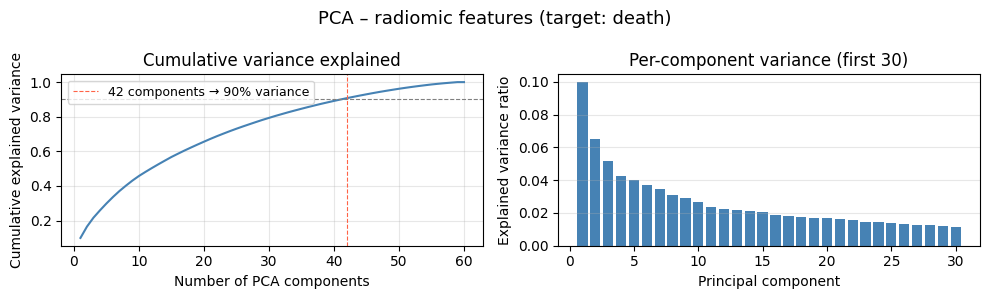

Components to reach 90% variance: 42 / 446
[Radiomic → death]  n=60  positives=24  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


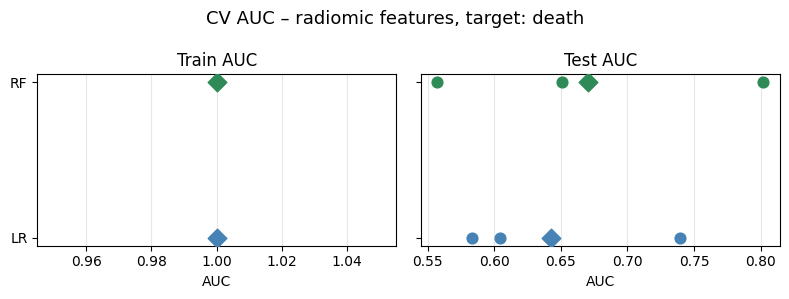

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → death,LR,0.642,0.069,0.700,0.071
1,Radiomic → death,RF,0.670,0.101,0.667,0.024


In [7]:
# === Experiment 1: Radiomic features only, target = death (from radiomics CSV) ===
X_exp1 = radiomic_features.set_index("SID")[radiomic_cols]
y_exp1 = radiomic_death.set_index("SID")["death"]
# Align (same source, but be explicit)
common = X_exp1.index.intersection(y_exp1.index)
X_exp1 = X_exp1.loc[common].reset_index(drop=True)
y_exp1 = y_exp1.loc[common].reset_index(drop=True)

X_pre1 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp1[~y_exp1.isna()])
plot_pca_variance(X_pre1, title="PCA – radiomic features (target: death)")

cv_results1, fold_df1 = run_cv_experiment(
    X_exp1, y_exp1, radiomic_x_columns, label="Radiomic → death"
)
plot_cv_results(fold_df1, title="CV AUC – radiomic features, target: death")
cv_results1

Experiment 2 dataset size: 60


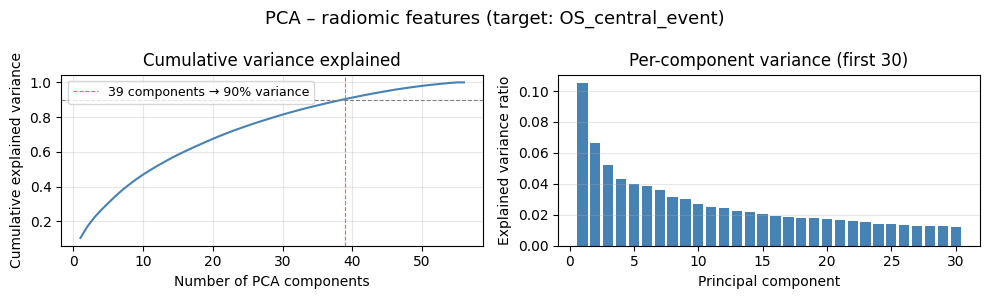

Components to reach 90% variance: 39 / 446
[Radiomic → OS_central_event]  n=56  positives=21  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


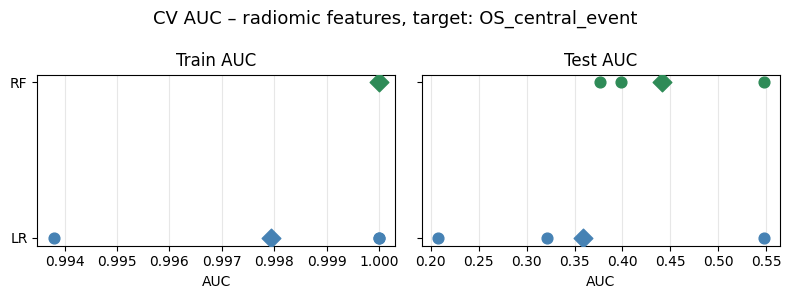

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → OS_central_event,LR,0.359,0.141,0.443,0.125
1,Radiomic → OS_central_event,RF,0.441,0.076,0.517,0.055


In [8]:
# === Experiment 2: Radiomic features only, target = OS_central_event (from clinical) ===
rad_with_clin_y = radiomic_features.merge(
    clinical_data[["SID", "OS_central_event"]], on="SID", how="inner"
)
print(f"Experiment 2 dataset size: {len(rad_with_clin_y)}")

X_exp2 = rad_with_clin_y[radiomic_cols].reset_index(drop=True)
y_exp2 = rad_with_clin_y["OS_central_event"].reset_index(drop=True)

X_pre2 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp2[~y_exp2.isna()])
plot_pca_variance(X_pre2, title="PCA – radiomic features (target: OS_central_event)")

cv_results2, fold_df2 = run_cv_experiment(
    X_exp2, y_exp2, radiomic_x_columns, label="Radiomic → OS_central_event"
)
plot_cv_results(fold_df2, title="CV AUC – radiomic features, target: OS_central_event")
cv_results2

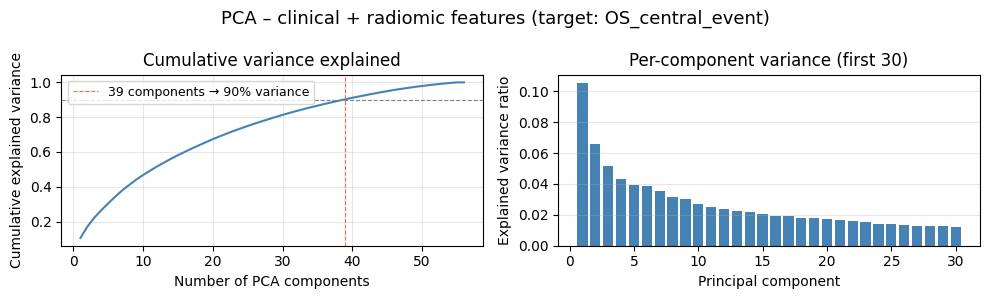

Components to reach 90% variance: 39 / 472
[Clinical+Radiomic → OS_central_event]  n=56  positives=21  features=457


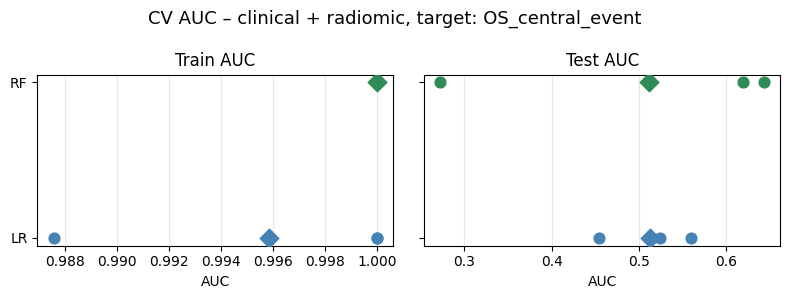

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Clinical+Radiomic → OS_central_event,LR,0.513,0.044,0.551,0.114
1,Clinical+Radiomic → OS_central_event,RF,0.512,0.169,0.588,0.075


In [9]:
# === Experiment 3: Clinical + Radiomic features, target = OS_central_event ===
X_exp3 = merged[list(combined_x_columns.keys())]
y_exp3 = merged["OS_central_event"]

X_pre3 = build_preprocessor(combined_x_columns).fit_transform(X_exp3[~y_exp3.isna()])
plot_pca_variance(
    X_pre3, title="PCA – clinical + radiomic features (target: OS_central_event)"
)

cv_results3, fold_df3 = run_cv_experiment(
    X_exp3, y_exp3, combined_x_columns, label="Clinical+Radiomic → OS_central_event"
)
plot_cv_results(
    fold_df3, title="CV AUC – clinical + radiomic, target: OS_central_event"
)
cv_results3

                          experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
                    Radiomic → death    LR     0.642    0.069          0.700         0.071
                    Radiomic → death    RF     0.670    0.101          0.667         0.024
         Radiomic → OS_central_event    LR     0.359    0.141          0.443         0.125
         Radiomic → OS_central_event    RF     0.441    0.076          0.517         0.055
Clinical+Radiomic → OS_central_event    LR     0.513    0.044          0.551         0.114
Clinical+Radiomic → OS_central_event    RF     0.512    0.169          0.588         0.075


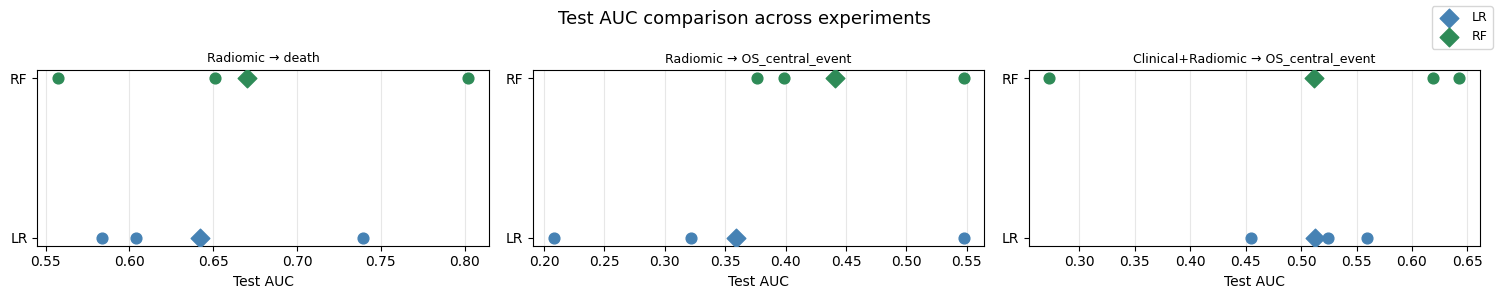

In [10]:
# === Combined comparison across all three experiments ===
all_cv = pd.concat([cv_results1, cv_results2, cv_results3], ignore_index=True)
all_folds = pd.concat([fold_df1, fold_df2, fold_df3], ignore_index=True)

print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds)

## With grid search

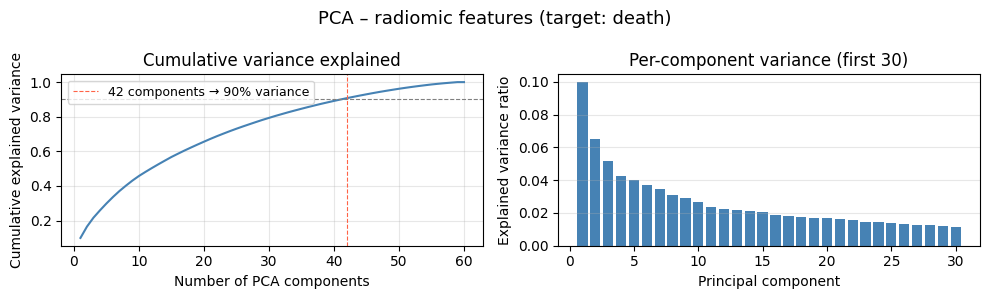

Components to reach 90% variance: 42 / 446
[Radiomic → death]  n=60  positives=24  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 0.5}
   LR     2             {'C': 1.0, 'l1_ratio': 1.0}
   LR     3            {'C': 10.0, 'l1_ratio': 0.5}
   RF     1 {'max_depth': 3, 'min_samples_leaf': 5}
   RF     2 {'max_depth': 5, 'min_samples_leaf': 1}
   RF     3 {'max_depth': 3, 'min_samples_leaf': 3}


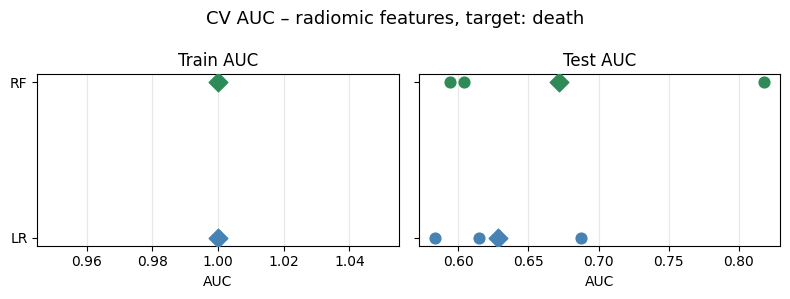

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → death,LR,0.628,0.044,0.633,0.024
1,Radiomic → death,RF,0.672,0.103,0.633,0.047


In [11]:
# === Experiment 1: Radiomic features only, target = death (from radiomics CSV) ===
X_exp1 = radiomic_features.set_index("SID")[radiomic_cols]
y_exp1 = radiomic_death.set_index("SID")["death"]
# Align (same source, but be explicit)
common = X_exp1.index.intersection(y_exp1.index)
X_exp1 = X_exp1.loc[common].reset_index(drop=True)
y_exp1 = y_exp1.loc[common].reset_index(drop=True)

X_pre1 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp1[~y_exp1.isna()])
plot_pca_variance(X_pre1, title="PCA – radiomic features (target: death)")

cv_results1, fold_df1 = run_cv_experiment(
    X_exp1,
    y_exp1,
    radiomic_x_columns,
    label="Radiomic → death",
    param_grids=PARAM_GRIDS,
)
print(fold_df1[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df1, title="CV AUC – radiomic features, target: death")
cv_results1

Experiment 2 dataset size: 60


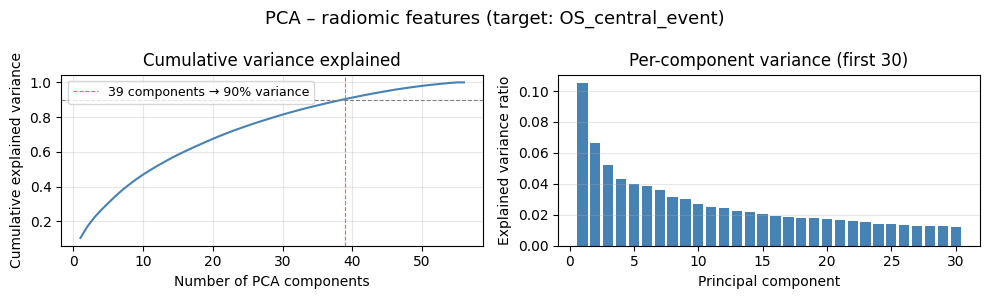

Components to reach 90% variance: 39 / 446
[Radiomic → OS_central_event]  n=56  positives=21  features=446


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                             best_params
   LR     1             {'C': 1.0, 'l1_ratio': 1.0}
   LR     2             {'C': 1.0, 'l1_ratio': 1.0}
   LR     3            {'C': 10.0, 'l1_ratio': 1.0}
   RF     1 {'max_depth': 5, 'min_samples_leaf': 1}
   RF     2 {'max_depth': 3, 'min_samples_leaf': 5}
   RF     3 {'max_depth': 5, 'min_samples_leaf': 1}


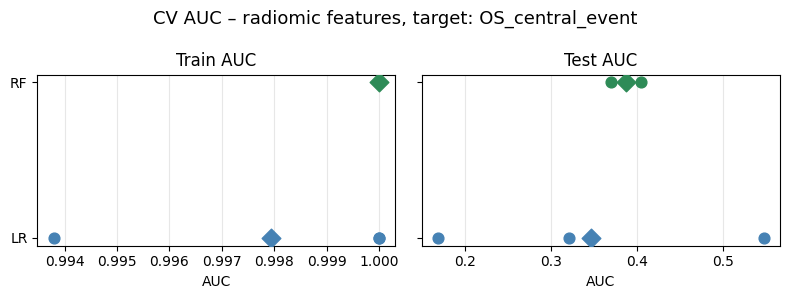

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Radiomic → OS_central_event,LR,0.346,0.156,0.443,0.125
1,Radiomic → OS_central_event,RF,0.387,0.014,0.517,0.055


In [12]:
# === Experiment 2: Radiomic features only, target = OS_central_event (from clinical) ===
rad_with_clin_y = radiomic_features.merge(
    clinical_data[["SID", "OS_central_event"]], on="SID", how="inner"
)
print(f"Experiment 2 dataset size: {len(rad_with_clin_y)}")

X_exp2 = rad_with_clin_y[radiomic_cols].reset_index(drop=True)
y_exp2 = rad_with_clin_y["OS_central_event"].reset_index(drop=True)

X_pre2 = build_preprocessor(radiomic_x_columns).fit_transform(X_exp2[~y_exp2.isna()])
plot_pca_variance(X_pre2, title="PCA – radiomic features (target: OS_central_event)")

cv_results2, fold_df2 = run_cv_experiment(
    X_exp2,
    y_exp2,
    radiomic_x_columns,
    label="Radiomic → OS_central_event",
    param_grids=PARAM_GRIDS,
)
print(fold_df2[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(fold_df2, title="CV AUC – radiomic features, target: OS_central_event")
cv_results2

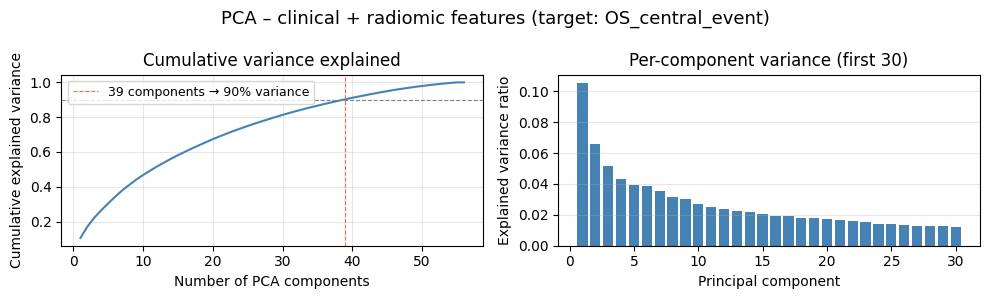

Components to reach 90% variance: 39 / 472
[Clinical+Radiomic → OS_central_event]  n=56  positives=21  features=457


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

model  fold                              best_params
   LR     1              {'C': 1.0, 'l1_ratio': 0.5}
   LR     2              {'C': 1.0, 'l1_ratio': 0.5}
   LR     3             {'C': 10.0, 'l1_ratio': 1.0}
   RF     1 {'max_depth': 10, 'min_samples_leaf': 1}
   RF     2  {'max_depth': 3, 'min_samples_leaf': 3}
   RF     3  {'max_depth': 3, 'min_samples_leaf': 5}


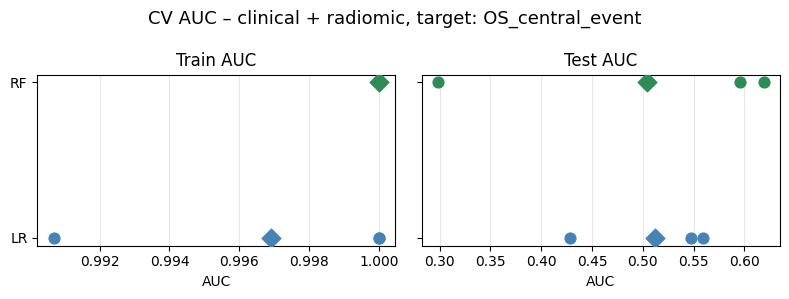

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,Clinical+Radiomic → OS_central_event,LR,0.512,0.059,0.569,0.088
1,Clinical+Radiomic → OS_central_event,RF,0.504,0.146,0.588,0.075


In [13]:
# === Experiment 3: Clinical + Radiomic features, target = OS_central_event ===
X_exp3 = merged[list(combined_x_columns.keys())]
y_exp3 = merged["OS_central_event"]

X_pre3 = build_preprocessor(combined_x_columns).fit_transform(X_exp3[~y_exp3.isna()])
plot_pca_variance(
    X_pre3, title="PCA – clinical + radiomic features (target: OS_central_event)"
)

cv_results3, fold_df3 = run_cv_experiment(
    X_exp3,
    y_exp3,
    combined_x_columns,
    label="Clinical+Radiomic → OS_central_event",
    param_grids=PARAM_GRIDS,
)
print(fold_df3[["model", "fold", "best_params"]].to_string(index=False))
plot_cv_results(
    fold_df3, title="CV AUC – clinical + radiomic, target: OS_central_event"
)
cv_results3

                          experiment model  AUC mean  AUC std  Accuracy mean  Accuracy std
                    Radiomic → death    LR     0.628    0.044          0.633         0.024
                    Radiomic → death    RF     0.672    0.103          0.633         0.047
         Radiomic → OS_central_event    LR     0.346    0.156          0.443         0.125
         Radiomic → OS_central_event    RF     0.387    0.014          0.517         0.055
Clinical+Radiomic → OS_central_event    LR     0.512    0.059          0.569         0.088
Clinical+Radiomic → OS_central_event    RF     0.504    0.146          0.588         0.075


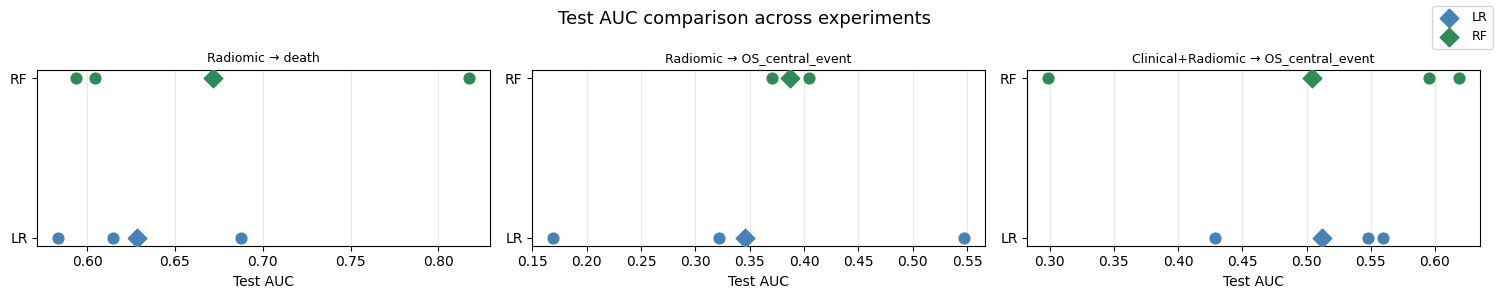

In [14]:
# === Combined comparison across all three experiments ===
all_cv = pd.concat([cv_results1, cv_results2, cv_results3], ignore_index=True)
all_folds = pd.concat([fold_df1, fold_df2, fold_df3], ignore_index=True)

print(all_cv.to_string(index=False))
plot_experiment_comparison(all_folds)